In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline   # shows plots inline in the notebook

In [3]:
df = pd.read_csv('../data/student-mat.csv', sep=';')
print("Dataset shape:", df.shape)   # (395, 33)
print(df.dtypes)

# Create binary target: 1 = at risk (fail), 0 = not at risk
df['at_risk'] = (df['G3'] < 10).astype(int)
print("\nAt-risk rate:", df['at_risk'].mean().round(2))
df.head()

Dataset shape: (395, 33)
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

At-risk rate: 0.33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,at_risk
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,0


Class distribution:
at_risk
0    265
1    130
Name: count, dtype: int64


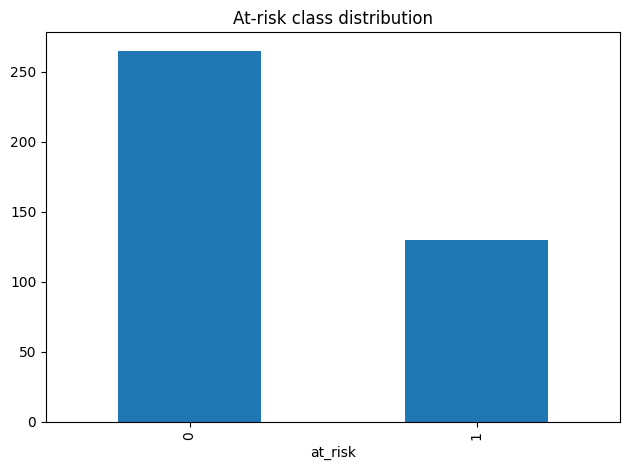

In [4]:
# Best behavioural features (NO G1/G2 — that's data leakage!)
FEATURES = ['absences','studytime','failures',
            'freetime','goout','Dalc','Walc',
            'health','famrel','traveltime']

# Class imbalance check
counts = df['at_risk'].value_counts()
print("Class distribution:")
print(counts)
counts.plot(kind='bar', title='At-risk class distribution')
plt.tight_layout()
plt.show()

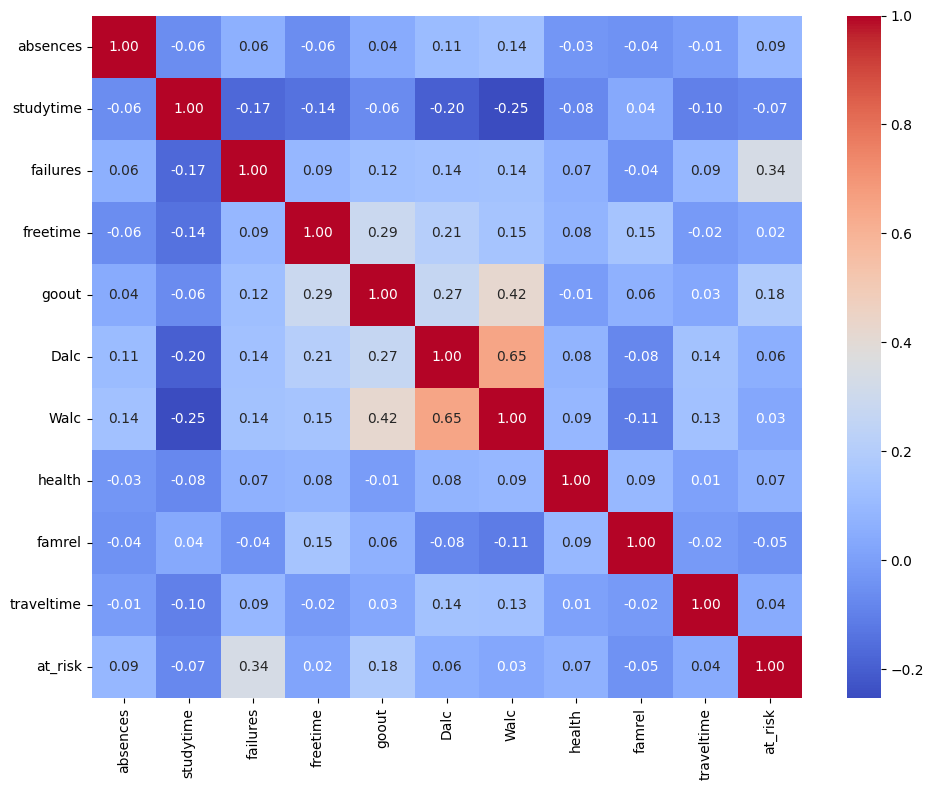

In [5]:
corr = df[FEATURES + ['at_risk']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()